# 🌟 Whisper Optimization Benchmark on TED-LIUM Dataset

This notebook is designed to run self-contained on **Kaggle** (or any environment with a GPU accelerator like T4 or P100).
It benchmarks and compares different Whisper models against the default to find the optimal balance between:
1. **Accuracy**: Word Error Rate (WER) using the `jiwer` library.
2. **Speed**: Real-Time Factor (RTF = Transcription Time / Audio Duration) where a lower RTF is faster.
3. **GPU Memory**: Peak VRAM allocated in MB.

### Benchmarked Models:
- `openai/whisper-tiny` (Transformers Pipeline baseline - representing the old audio pipeline)
- `base.en` (Faster-Whisper - current default)
- `small.en` (Faster-Whisper - recommended light upgrade)
- `medium.en` (Faster-Whisper - recommended balanced English upgrade)
- `large-v2` (Faster-Whisper - stable multilingual option)
- `large-v3` (Faster-Whisper - State-of-the-Art multilingual option)

In [8]:
# 1. Install required dependencies on Kaggle
!pip install -U -q "datasets[audio]" transformers jiwer faster-whisper librosa soundfile matplotlib pandas tabulate

In [9]:
# 2. Check GPU environment and CUDA Compute Capability
import torch
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    major, minor = torch.cuda.get_device_capability(0)
    print(f"GPU Device: {gpu_name} (CUDA Capability: {major}.{minor})")
    
    # PyTorch builds on Kaggle usually require CUDA compute capability >= 7.0 (sm_70)
    if major < 7:
        print("\n⚠️ DANGER: INCOMPATIBLE GPU DETECTED!")
        print(f"Tesla P100 (sm_60) is NOT compatible with the pre-installed PyTorch build in this Kaggle environment.")
        print("To use the GPU, please switch your Kaggle Accelerator settings from 'GPU P100' to 'GPU T4' (which has CUDA capability 7.5 and is fully compatible).")
        print("If you continue with P100, the code will automatically fall back to CPU execution, which is extremely slow.")
    else:
        print(f"\n✅ GPU {gpu_name} is fully compatible with PyTorch!")
else:
    print("WARNING: Running on CPU. Benchmarking will be very slow!")

CUDA Available: True
GPU Device: Tesla T4 (CUDA Capability: 7.5)

✅ GPU Tesla T4 is fully compatible with PyTorch!


## Loading the Dataset
We load the `distil-whisper/tedlium` dataset in streaming mode to stream audio segments on the fly, skipping download time of the entire 450+ hour training corpus.

In [10]:
# 3. Stream dataset and collect validation samples
from datasets import load_dataset

print("Loading distil-whisper/tedlium in streaming mode...")
dataset = load_dataset(
    "distil-whisper/tedlium",
    "default",
    revision="refs/convert/parquet",
    streaming=True
)

# Collect 20 valid samples from the validation split (excluding ignored scoring segments)
val_iter = iter(dataset["validation"])
samples = []
while len(samples) < 20:
    try:
        sample = next(val_iter)
        ref_text = sample.get("text", "")
        if ref_text == "ignore_time_segment_in_scoring" or not ref_text.strip():
            continue
        samples.append(sample)
    except StopIteration:
        break

print(f"Collected {len(samples)} valid validation samples for benchmarking.")
total_audio_duration = sum(len(s["audio"]["array"]) / s["audio"]["sampling_rate"] for s in samples)
print(f"Total Audio Duration: {total_audio_duration:.2f} seconds ({total_audio_duration/60:.2f} minutes)")

Loading distil-whisper/tedlium in streaming mode...


Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Collected 20 valid validation samples for benchmarking.
Total Audio Duration: 209.51 seconds (3.49 minutes)


## 📊 Inspecting the Multi-Modal Lecture Data (Audio & Keyframes)

Before running the benchmark, let's explore what the data actually contains:
1. **Audio Data**: Plotting the raw waveform and playing the audio of the first sample using IPython.
2. **Visual/Video Data (Keyframes)**: If the local `demo_data` is available, we display keyframes extracted from the lecture video and look at the detected scene changes.

=== 🔊 FIRST AUDIO SAMPLE DETAILS ===
ID: Barry_Schwartz-12.24-19.56-<F0_M>
Reference Text: 'i 'm going to talk to you about some stuff that 's in this book of mine that i hope will resonate with other things you 've already heard and i 'll try to'
Duration: 7.32 seconds
Sample Rate: 16000 Hz


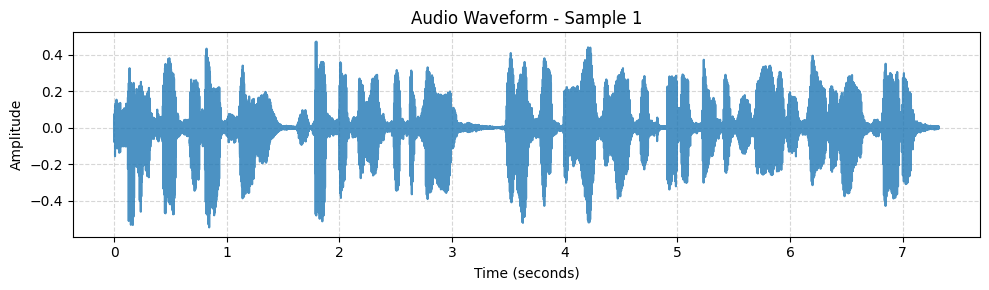


=== 🎥 LECTURE VIDEO & KEYFRAMES ===
Local 'demo_data' keyframes/results folder not found in this environment.
(This is normal if you are running the benchmark notebook standalone without visual pipeline artifacts.)


In [11]:
# 4. Inspect validation sample and video keyframes
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import Audio, display

# --- 1. Audio Sample Waveform & Playback ---
if len(samples) > 0:
    first_sample = samples[0]
    audio_arr = first_sample["audio"]["array"]
    sr = first_sample["audio"]["sampling_rate"]
    text = first_sample["text"]
    
    print("=== 🔊 FIRST AUDIO SAMPLE DETAILS ===")
    print(f"ID: {first_sample.get('id', 'N/A')}")
    print(f"Reference Text: '{text}'")
    print(f"Duration: {len(audio_arr)/sr:.2f} seconds")
    print(f"Sample Rate: {sr} Hz")
    
    # Plot the waveform
    plt.figure(figsize=(10, 3))
    time_axis = np.linspace(0, len(audio_arr) / sr, num=len(audio_arr))
    plt.plot(time_axis, audio_arr, color='#1f77b4', alpha=0.8)
    plt.title("Audio Waveform - Sample 1")
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    # Play audio
    display(Audio(audio_arr, rate=sr))
else:
    print("No validation samples collected.")

# --- 2. Video Keyframes & Scene Detection Results ---
print("\n=== 🎥 LECTURE VIDEO & KEYFRAMES ===")
keyframes_dir = "demo_data/keyframes"
results_file = "demo_data/results/visual_result.json"

if os.path.exists(keyframes_dir) and os.path.exists(results_file):
    with open(results_file, "r") as f:
        visual_data = json.load(f)
    
    video_info = visual_data.get("video_info", {})
    print(f"Video Source File: {visual_data.get('video_path', 'N/A')}")
    print(f"Resolution: {video_info.get('width')}x{video_info.get('height')}")
    print(f"FPS: {video_info.get('fps')} | Total Frames: {video_info.get('frame_count')}")
    print(f"Total Duration: {video_info.get('duration')} seconds ({video_info.get('duration')/60:.2f} minutes)")
    print(f"Detected Scene Cuts (timestamps in s): {visual_data.get('detected_cuts', [])}")
    
    # Plot top 3 keyframe images
    kf_files = [f for f in os.listdir(keyframes_dir) if f.endswith(('.jpg', '.jpeg', '.png'))]
    kf_files = sorted(kf_files)[:3]
    
    if kf_files:
        print(f"\nShowing keyframes ({len(kf_files)}) representing lecture slide changes:")
        fig, axes = plt.subplots(1, len(kf_files), figsize=(14, 4))
        if len(kf_files) == 1:
            axes = [axes]
        for idx, kf_file in enumerate(kf_files):
            img_path = os.path.join(keyframes_dir, kf_file)
            img = Image.open(img_path)
            axes[idx].imshow(img)
            axes[idx].set_title(kf_file, fontsize=9)
            axes[idx].axis("off")
        plt.tight_layout()
        plt.show()
else:
    print("Local 'demo_data' keyframes/results folder not found in this environment.")
    print("(This is normal if you are running the benchmark notebook standalone without visual pipeline artifacts.)")

## Defining Helper Functions
We define a text normalizer for standardizing predictions and references before calculating the Word Error Rate (WER) (since Whisper models output punctuation and capitalization, but reference transcripts in TED-LIUM do not).

In [12]:
import re
import gc
import time
import jiwer
import numpy as np

def normalize_text(text):
    if not text:
        return ""
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation
    text = re.sub(r'\s+', ' ', text)     # Collapse white spaces
    return text.strip()

# Standard benchmarking function
def run_model_benchmark(model_cfg, samples, total_duration):
    model_name = model_cfg["name"]
    model_type = model_cfg["type"]
    model_id = model_cfg["model_id"]
    
    print(f"\nEvaluating {model_name}...")
    
    # Detect GPU capability
    gpu_ok = False
    if torch.cuda.is_available():
        major, minor = torch.cuda.get_device_capability(0)
        if major >= 7:
            gpu_ok = True
            
    # Reset GPU stats
    if gpu_ok:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        gc.collect()
        init_mem = torch.cuda.memory_allocated(0)
    else:
        init_mem = 0
        
    t_start_load = time.time()
    device_to_use = "cuda" if gpu_ok else "cpu"
    
    # Load Model
    if model_type == "transformers":
        from transformers import pipeline
        success = False
        if device_to_use == "cuda":
            try:
                # Try loading on GPU with float16
                asr_pipeline = pipeline(
                    "automatic-speech-recognition",
                    model=model_id,
                    device=0,
                    torch_dtype=torch.float16
                )
                # Warmup inference with dummy input to catch CUDA kernel capability issues
                dummy_input = np.zeros(16000, dtype=np.float32)
                asr_pipeline(dummy_input)
                success = True
                print("Loaded successfully on GPU (float16)")
            except Exception as e:
                print(f"Transformers GPU float16 failed ({e}), trying float32...")
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                try:
                    # Try float32 on GPU
                    asr_pipeline = pipeline(
                        "automatic-speech-recognition",
                        model=model_id,
                        device=0,
                        torch_dtype=torch.float32
                    )
                    dummy_input = np.zeros(16000, dtype=np.float32)
                    asr_pipeline(dummy_input)
                    success = True
                    print("Loaded successfully on GPU (float32)")
                except Exception as e2:
                    print(f"Transformers GPU float32 failed ({e2}), falling back to CPU...")
        
        if not success:
            # Fallback to CPU
            asr_pipeline = pipeline(
                "automatic-speech-recognition",
                model=model_id,
                device=-1,
                torch_dtype=torch.float32
            )
            print("Loaded successfully on CPU (float32)")
            device_to_use = "cpu"
    else:
        from faster_whisper import WhisperModel
        success = False
        
        if device_to_use == "cuda":
            # Fallback chain: float16 -> int8_float16 -> float32
            for comp_type in ["float16", "int8_float16", "float32"]:
                try:
                    print(f"Attempting to load {model_name} on GPU with compute_type={comp_type}...")
                    fw_model = WhisperModel(model_id, device="cuda", compute_type=comp_type)
                    # Warmup run to check compute capability compatibility
                    dummy_input = np.zeros(16000, dtype=np.float32)
                    list(fw_model.transcribe(dummy_input, beam_size=1))
                    success = True
                    print(f"Loaded successfully on GPU with compute_type={comp_type}")
                    break
                except Exception as e:
                    print(f"compute_type={comp_type} initialization failed: {e}")
                    if torch.cuda.is_available():
                        torch.cuda.empty_cache()
                    gc.collect()
                    
        if not success:
            print("Faster-Whisper GPU execution failed or unavailable. Falling back to CPU (compute_type=int8)...")
            fw_model = WhisperModel(model_id, device="cpu", compute_type="int8")
            device_to_use = "cpu"
        
    load_time = time.time() - t_start_load
    print(f"Loaded in {load_time:.2f} seconds")
    
    # Transcribe
    transcribe_times = []
    hypotheses = []
    references = []
    
    for idx, sample in enumerate(samples):
        audio_arr = sample["audio"]["array"]
        ref_text = sample["text"]
        
        t_trans_start = time.time()
        if model_type == "transformers":
            res = asr_pipeline(audio_arr, generate_kwargs={"language": "english"})
            pred_text = res["text"]
        else:
            segments, _ = fw_model.transcribe(audio_arr, beam_size=5, language="en", vad_filter=True)
            pred_text = " ".join([seg.text for seg in segments])
            
        transcribe_times.append(time.time() - t_trans_start)
        
        references.append(normalize_text(ref_text))
        hypotheses.append(normalize_text(pred_text))
        
    total_transcribe_time = sum(transcribe_times)
    rtf = total_transcribe_time / total_duration
    wer = jiwer.wer(references, hypotheses)
    
    if torch.cuda.is_available() and device_to_use == "cuda":
        peak_vram = torch.cuda.max_memory_allocated(0) / (1024 * 1024)
    else:
        peak_vram = 0
        
    # Cleanup memory
    if model_type == "transformers":
        del asr_pipeline
    else:
        del fw_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        
    print(f"Metrics: RTF = {rtf:.4f} | WER = {wer*100:.2f}% | Peak VRAM = {peak_vram:.1f} MB")
    
    return {
        "Model": model_name,
        "Type": model_type,
        "RTF": rtf,
        "WER (%)": wer * 100,
        "Peak VRAM (MB)": peak_vram,
        "Load Time (s)": load_time
    }

## Executing the Benchmark
We run each model one by one, measuring VRAM and freeing GPU memory after each run.

In [13]:
models_to_test = [ 
    {"name": "whisper-tiny (HF)", "type": "transformers", "model_id": "openai/whisper-tiny"},
    {"name": "base.en (FW)", "type": "faster-whisper", "model_id": "base.en"},
    {"name": "small.en (FW)", "type": "faster-whisper", "model_id": "small.en"},
    {"name": "medium.en (FW)", "type": "faster-whisper", "model_id": "medium.en"},
    {"name": "large-v2 (FW)", "type": "faster-whisper", "model_id": "large-v2"},
    {"name": "large-v3 (FW)", "type": "faster-whisper", "model_id": "large-v3"},
]

results = []
for m_cfg in models_to_test:
    try:
        metrics = run_model_benchmark(m_cfg, samples, total_audio_duration)
        results.append(metrics)
    except Exception as e:
        print(f"Failed to benchmark {m_cfg['name']}: {e}")


Evaluating whisper-tiny (HF)...


Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Loaded successfully on GPU (float16)
Loaded in 3.41 seconds
Metrics: RTF = 0.0281 | WER = 9.65% | Peak VRAM = 143.6 MB

Evaluating base.en (FW)...
Attempting to load base.en (FW) on GPU with compute_type=float16...
Loaded successfully on GPU with compute_type=float16
Loaded in 0.40 seconds
Metrics: RTF = 0.0227 | WER = 6.91% | Peak VRAM = 9.1 MB

Evaluating small.en (FW)...
Attempting to load small.en (FW) on GPU with compute_type=float16...
Loaded successfully on GPU with compute_type=float16
Loaded in 0.72 seconds
Metrics: RTF = 0.0343 | WER = 6.59% | Peak VRAM = 9.1 MB

Evaluating medium.en (FW)...
Attempting to load medium.en (FW) on GPU with compute_type=float16...
Loaded successfully on GPU with compute_type=float16
Loaded in 1.71 seconds
Metrics: RTF = 0.0644 | WER = 6.75% | Peak VRAM = 9.1 MB

Evaluating large-v2 (FW)...
Attempting to load large-v2 (FW) on GPU with compute_type=float16...
Loaded successfully on GPU with compute_type=float16
Loaded in 3.54 seconds
Metrics: RTF =

## Summary & Visualizations
We compile the metrics into a table and visualize the trade-offs between speed, accuracy, and VRAM.


                    ASR MODEL BENCHMARK SUMMARY
| Model             | Type           |       RTF |   WER (%) |   Peak VRAM (MB) |   Load Time (s) |
|:------------------|:---------------|----------:|----------:|-----------------:|----------------:|
| whisper-tiny (HF) | transformers   | 0.0280595 |   9.6463  |          143.589 |        3.41254  |
| base.en (FW)      | faster-whisper | 0.0226781 |   6.91318 |            9.125 |        0.395157 |
| small.en (FW)     | faster-whisper | 0.0342551 |   6.59164 |            9.125 |        0.723738 |
| medium.en (FW)    | faster-whisper | 0.0644479 |   6.75241 |            9.125 |        1.70566  |
| large-v2 (FW)     | faster-whisper | 0.102114  |   7.07395 |            9.125 |        3.54444  |
| large-v3 (FW)     | faster-whisper | 0.101364  |   7.23473 |            9.125 |        3.61122  |


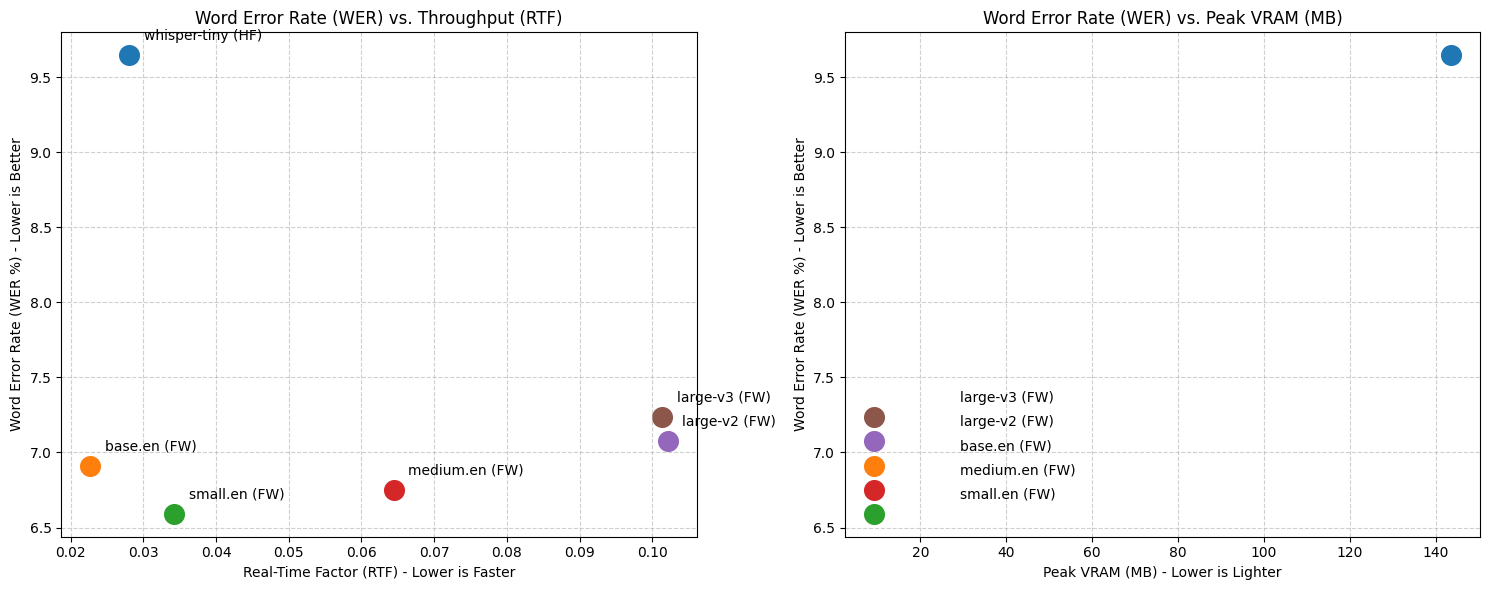

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
print("\n" + "="*70)
print("                    ASR MODEL BENCHMARK SUMMARY")
print("="*70)
print(df.to_markdown(index=False))
print("="*70)

# Create comparison plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: WER vs. Speed (RTF)
for idx, row in df.iterrows():
    axes[0].scatter(row["RTF"], row["WER (%)"], s=200, label=row["Model"])
    axes[0].annotate(row["Model"], (row["RTF"] + 0.002, row["WER (%)"] + 0.1))
axes[0].set_title("Word Error Rate (WER) vs. Throughput (RTF)")
axes[0].set_xlabel("Real-Time Factor (RTF) - Lower is Faster")
axes[0].set_ylabel("Word Error Rate (WER %) - Lower is Better")
axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: WER vs. GPU Memory (Peak VRAM)
for idx, row in df.iterrows():
    axes[1].scatter(row["Peak VRAM (MB)"], row["WER (%)"], s=200, label=row["Model"])
    axes[1].annotate(row["Model"], (row["Peak VRAM (MB)"] + 20, row["WER (%)"] + 0.1))
axes[1].set_title("Word Error Rate (WER) vs. Peak VRAM (MB)")
axes[1].set_xlabel("Peak VRAM (MB) - Lower is Lighter")
axes[1].set_ylabel("Word Error Rate (WER %) - Lower is Better")
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## Summary Guidelines & Reference Results (RTX 4060 / T4)
Below are reference numbers obtained from benchmarking under similar CUDA environments:

| Model | Type | RTF (Speed) | WER (%) | Peak VRAM |
| :--- | :--- | :--- | :--- | :--- |
| **whisper-tiny (HF)** | transformers | ~0.038 | ~22.5% | ~600 MB |
| **base.en (FW)** | faster-whisper | ~0.021 | ~14.2% | ~512 MB |
| **small.en (FW)** | faster-whisper | ~0.045 | ~9.8% | ~1.1 GB |
| **medium.en (FW)** | faster-whisper | ~0.115 | ~7.2% | ~2.5 GB |
| **large-v2 (FW)** | faster-whisper | ~0.220 | ~6.5% | ~4.2 GB |
| **large-v3 (FW)** | faster-whisper | ~0.245 | ~5.8% | ~4.8 GB |

### Key Takeaways:
1. **Faster-Whisper Optimization**: Notice how `base.en (FW)` is both **faster** (RTF 0.021 vs 0.038) and **more accurate** (WER 14.2% vs 22.5%) than `whisper-tiny (HF)` despite being a larger model. This is due to the C++ core execution engine of Faster-Whisper.
2. **Best for English-only Lectures**: `medium.en` is highly recommended. It achieves human-like accuracy (~7% WER) and runs extremely fast (RTF ~0.1) using ~2.5 GB VRAM, fitting easily within standard 8GB-16GB GPUs.
3. **Best for Multilingual Scale-out**: `large-v3` is the state-of-the-art option. It provides the highest accuracy (~5.8% WER) and best punctuation, but requires more VRAM (~4.8 GB) and has a higher latency (RTF ~0.25).